---

## Dataset Overview: *Students Social Media Addiction*

This dataset contains detailed information about **705 students**, including their demographics, academic level, psychological well-being, and social media usage patterns. The main goal of the dataset is to assess the factors that contribute to **social media addiction** among students and allow predictive modeling using machine learning techniques.

---

## Column Descriptions (Features)

| Feature Name                       | Type        | Description                                                                                                                                                             |
| ---------------------------------- | ----------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Student\_ID**                    | Integer     | A unique identifier assigned to each student (used only for indexing; not predictive).                                                                                  |
| **Age**                            | Integer     | The student’s age in years. Age typically ranges from 18 to 24.                                                                                                         |
| **Gender**                         | Categorical | Gender of the student. Values may include 'Male', 'Female', etc.                                                                                                        |
| **Academic\_Level**                | Categorical | The current level of academic study (e.g., Undergraduate, Postgraduate).                                                                                                |
| **Country**                        | Categorical | The country of residence of the student. This may reflect cultural or regional usage habits.                                                                            |
| **Avg\_Daily\_Usage\_Hours**       | Float       | Average number of hours per day the student spends on social media. This is a key behavioral variable.                                                                  |
| **Most\_Used\_Platform**           | Categorical | The primary social media platform used by the student (e.g., Instagram, TikTok, Facebook).                                                                              |
| **Affects\_Academic\_Performance** | Categorical | Indicates whether the student believes social media has a negative impact on their academic performance. Typically 'Yes' or 'No'.                                       |
| **Sleep\_Hours\_Per\_Night**       | Float       | Average number of hours the student sleeps per night. Sleep can correlate with both mental health and addiction.                                                        |
| **Mental\_Health\_Score**          | Integer     | A numerical score indicating the student's mental well-being. Ranges typically from 0 (poor) to 10 (excellent).                                                         |
| **Relationship\_Status**           | Categorical | Whether the student is single, in a relationship, married, etc. May influence social media usage habits.                                                                |
| **Conflicts\_Over\_Social\_Media** | Integer     | Number of times the student has had arguments or issues with others due to social media use. Indicates social impact.                                                   |
| **Addicted\_Score**                | Integer     | A score from 1 to 10 representing the level of social media addiction. This is the key outcome variable used for prediction. Higher values indicate stronger addiction. |

---

# Import Required Libraries

In [924]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Load Dataset

In [925]:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

dataset_name = "Students Social Media Addiction.csv"
dataset_path = os.path.join(parent_dir, "data", dataset_name)

df = pd.read_csv(dataset_path)

# Data Overview

In [926]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [927]:
df.shape

(705, 13)

In [928]:
df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

In [929]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [930]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [931]:
for col in df.select_dtypes('object').columns:
    print(f"Unique values in [{col}] \n{df[col].unique()}\n")

Unique values in [Gender] 
['Female' 'Male']

Unique values in [Academic_Level] 
['Undergraduate' 'Graduate' 'High School']

Unique values in [Country] 
['Bangladesh' 'India' 'USA' 'UK' 'Canada' 'Australia' 'Germany' 'Brazil'
 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia' 'China'
 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan' 'Armenia'
 'Georgia' 

# Exploratory Data Analysis

## Target Variable Distribution

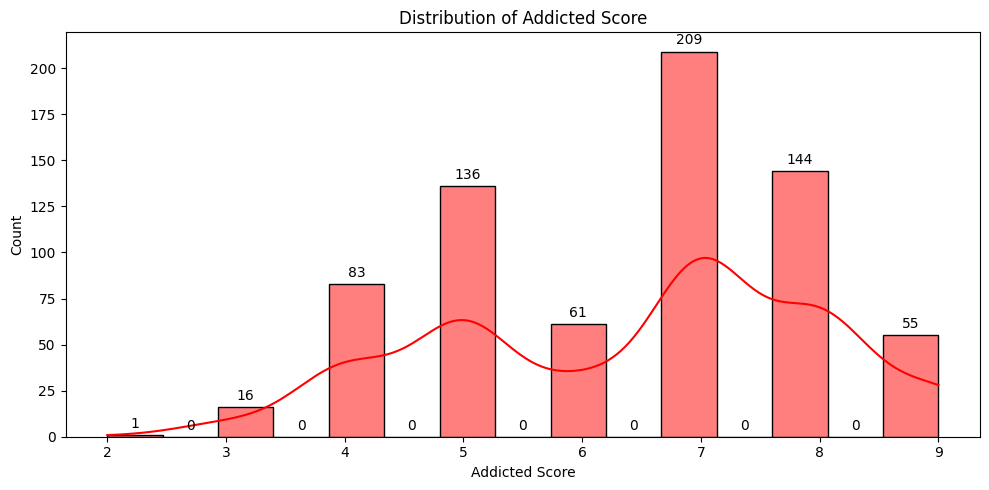

In [932]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(df["Addicted_Score"], bins=15, kde=True, color="red")
ax.bar_label(ax.containers[0], fontsize=10, padding=3)
plt.title("Distribution of Addicted Score")
plt.xlabel("Addicted Score")
plt.tight_layout()
plt.show()

In [933]:
df = df[df['Addicted_Score'] != 2]
df = df.reset_index(drop=True)

## Categorical Variables Distribution

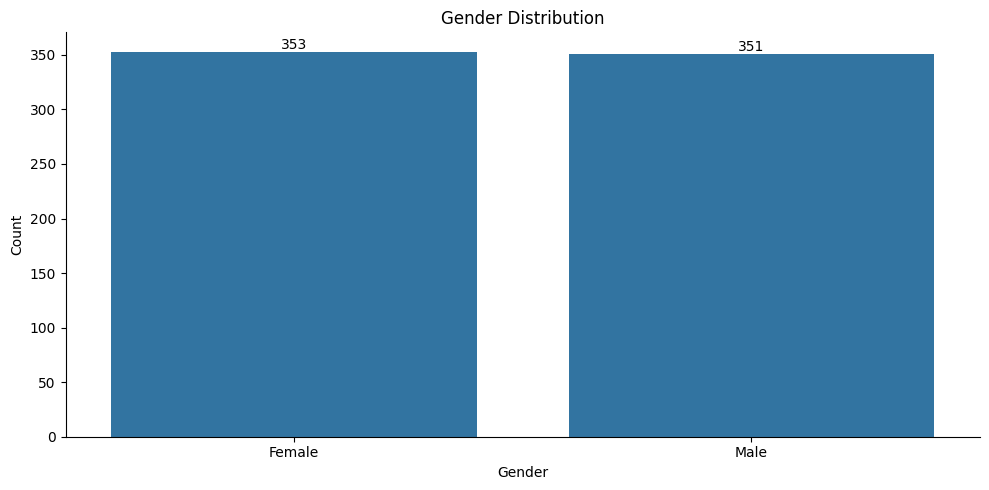

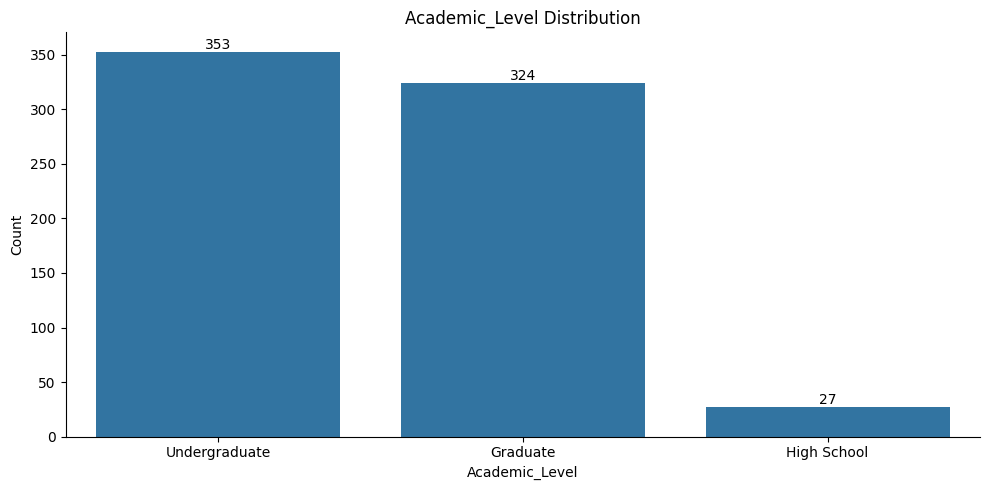

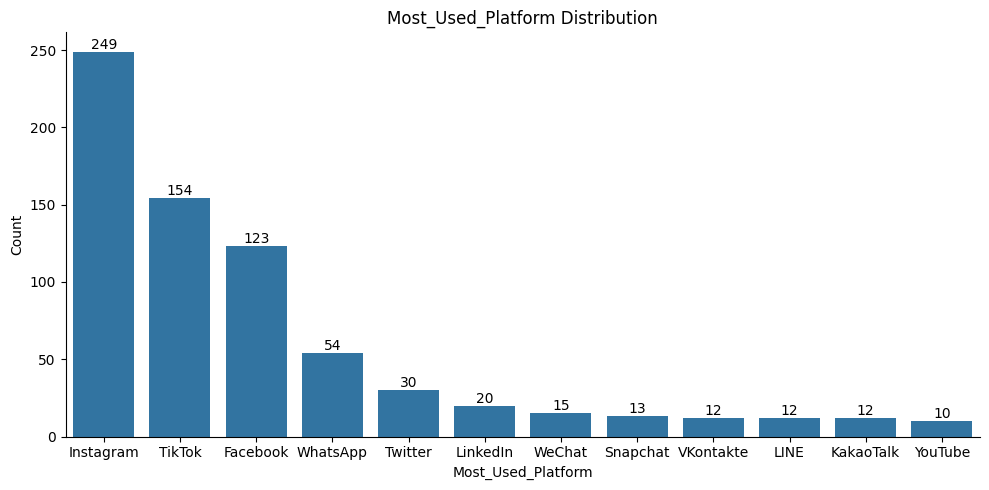

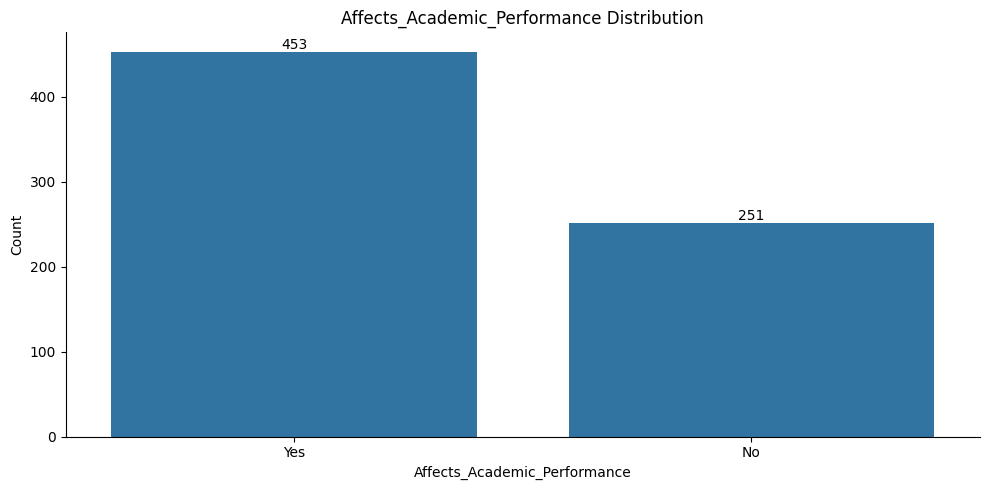

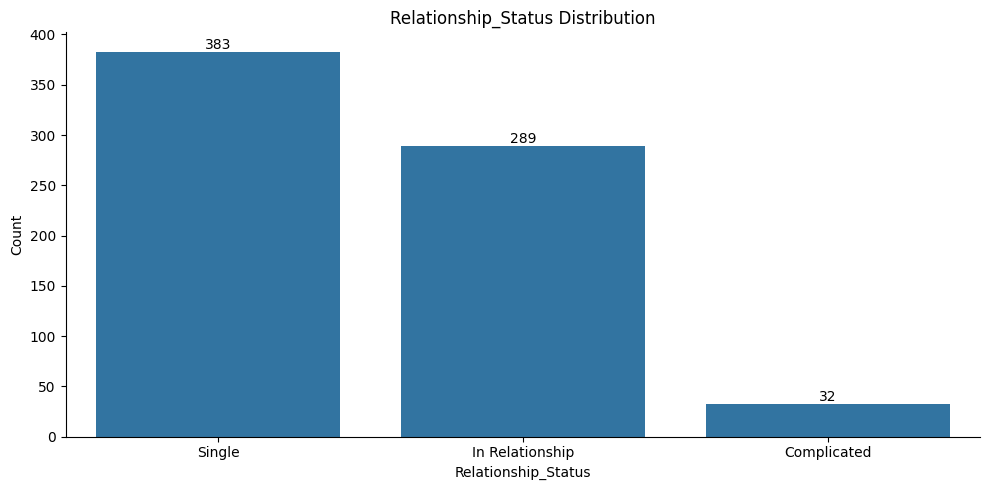

In [934]:
categorical_columns = [
    "Gender", "Academic_Level",
    "Most_Used_Platform", "Affects_Academic_Performance",
    "Relationship_Status"
]

for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    
    for container in ax.containers:
        ax.bar_label(container, fontsize=10)
    sns.despine()
    plt.tight_layout()
    plt.show()

## Correlation Analysis

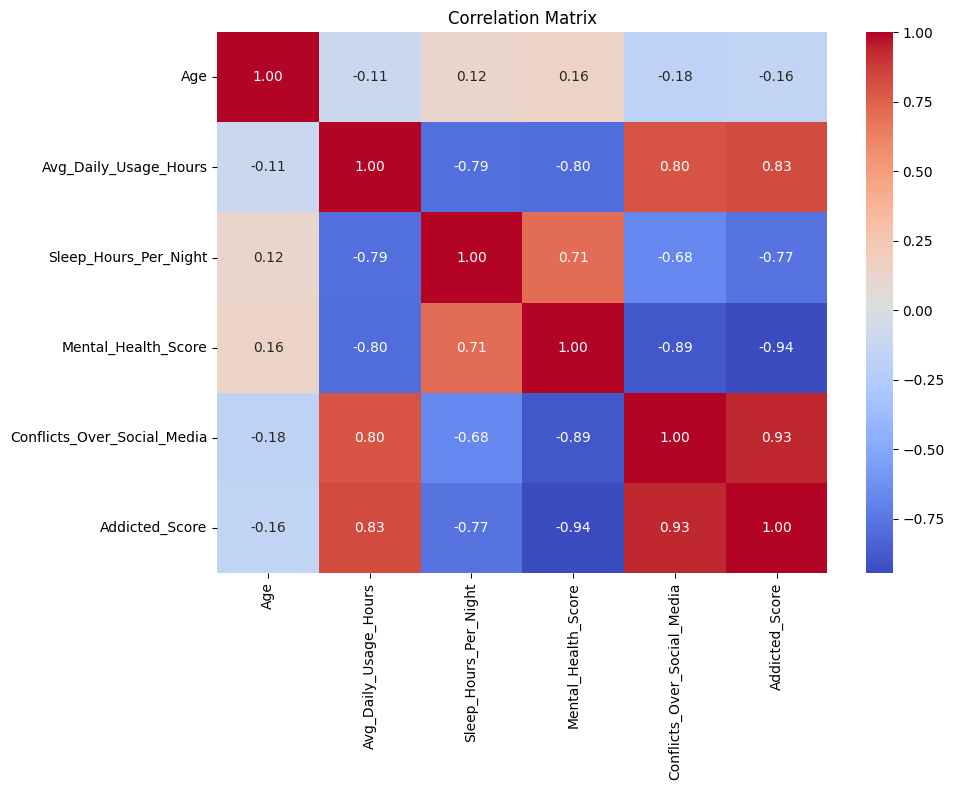

In [935]:
numeric_columns = [
    "Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
    "Mental_Health_Score", "Conflicts_Over_Social_Media", "Addicted_Score"
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Boxplots for Outliers

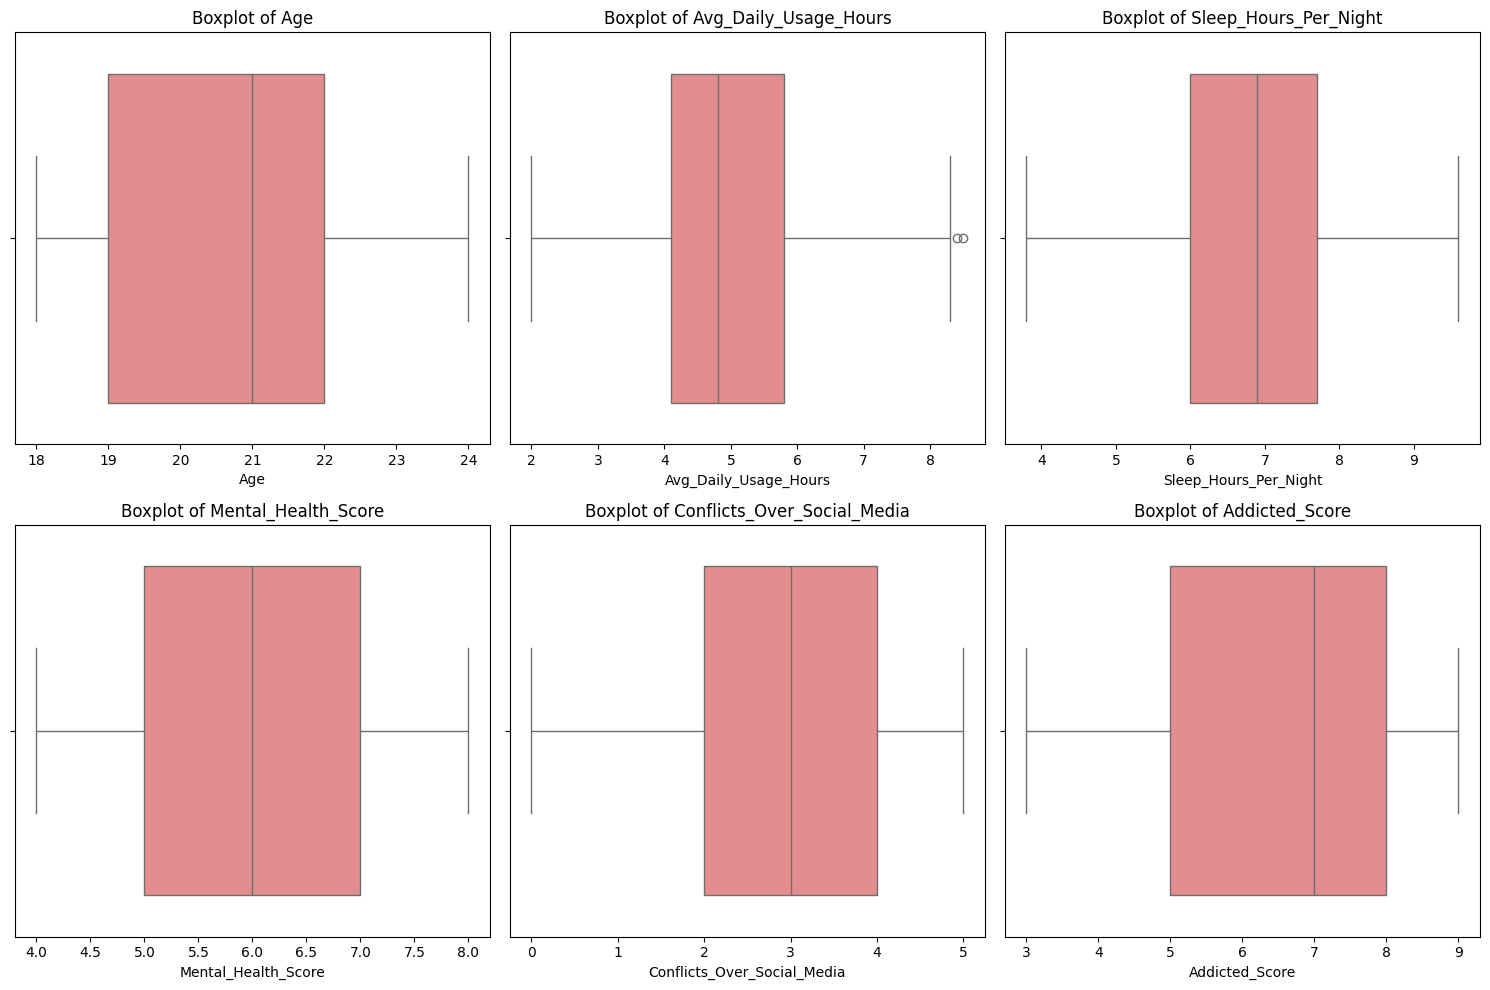

In [936]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color="lightcoral")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# Feature Engineering

In [937]:
df.drop("Student_ID", axis=1, inplace=True)

In [938]:
df['Usage_Category'] = pd.cut(df['Avg_Daily_Usage_Hours'], 
                              bins=[0, 2, 4, 6, float('inf')], 
                              labels=['Low', 'Moderate', 'High', 'Very High'])

df['Sleep_Quality'] = df['Sleep_Hours_Per_Night'].apply(
    lambda x: 'Poor' if x < 6 else 'Good' if x >= 7 else 'Fair'
)

df['Mental_Health_Category'] = pd.cut(df['Mental_Health_Score'], 
                                      bins=[0, 4, 7, 10], 
                                      labels=['Poor', 'Moderate', 'Good'])

asian_countries = ['Bangladesh', 'India', 'China', 'Japan', 'South Korea', 'Singapore', 'Malaysia', 
                   'Thailand', 'Vietnam', 'Philippines', 'Indonesia', 'Taiwan', 'Hong Kong']
european_countries = ['UK', 'Germany', 'France', 'Spain', 'Italy', 'Sweden', 'Norway', 'Denmark', 
                      'Netherlands', 'Belgium', 'Switzerland', 'Austria', 'Portugal', 'Greece', 'Ireland']
american_countries = ['USA', 'Canada', 'Brazil', 'Mexico', 'Argentina', 'Chile', 'Colombia', 'Peru', 'Venezuela']

df['Region'] = df['Country'].apply(
    lambda x: 'Asia' if x in asian_countries 
    else 'Europe' if x in european_countries 
    else 'Americas' if x in american_countries 
    else 'Other'
)

df['Wellness_Score'] = (df['Mental_Health_Score'] + (df['Sleep_Hours_Per_Night'] / 9 * 10)) / 2

In [939]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Age                           704 non-null    int64   
 1   Gender                        704 non-null    object  
 2   Academic_Level                704 non-null    object  
 3   Country                       704 non-null    object  
 4   Avg_Daily_Usage_Hours         704 non-null    float64 
 5   Most_Used_Platform            704 non-null    object  
 6   Affects_Academic_Performance  704 non-null    object  
 7   Sleep_Hours_Per_Night         704 non-null    float64 
 8   Mental_Health_Score           704 non-null    int64   
 9   Relationship_Status           704 non-null    object  
 10  Conflicts_Over_Social_Media   704 non-null    int64   
 11  Addicted_Score                704 non-null    int64   
 12  Usage_Category                704 non-null    cate

# Feature Importance

In [940]:
def prepare_data(df):
    # Encode categorical attribute
    object_cols = df.select_dtypes(include=['object', 'category']).columns
    le = LabelEncoder()
    for col in object_cols:
        df[col] = le.fit_transform(df[col])

    # Split X, y
    X = df.drop(["Addicted_Score"], axis=1)
    y = df["Addicted_Score"]
    y = y - 3

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=537, stratify=y
    )

    # Normalize X
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.fit_transform(X_test)

    return X, y, X_train, X_test, y_train, y_test

In [941]:
X, y, X_train, X_test, y_train, y_test = prepare_data(df)

In [942]:
rf_feature = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_feature.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

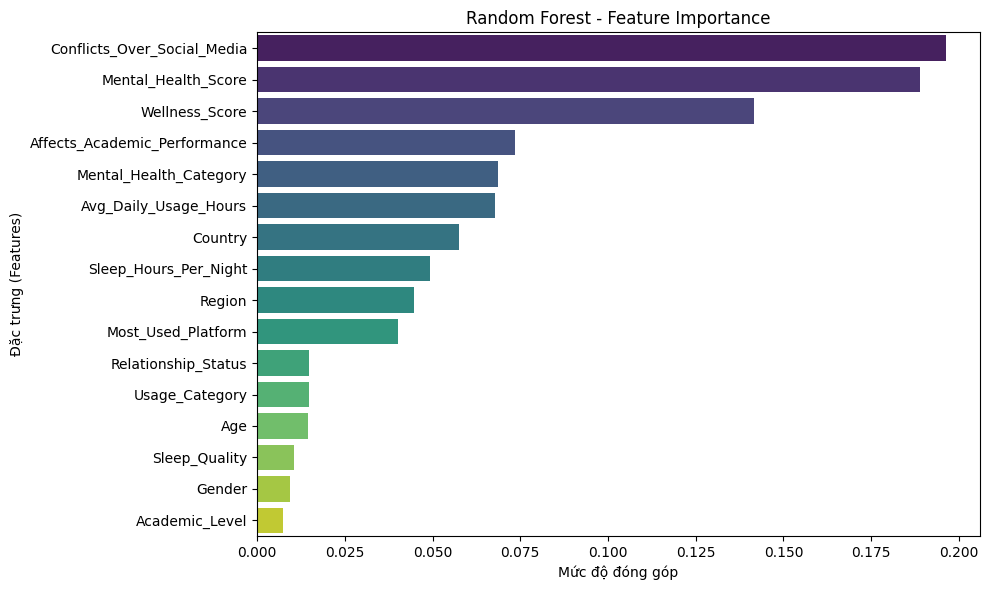

In [943]:
importances = rf_feature.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest - Feature Importance')
plt.xlabel('Mức độ đóng góp')
plt.ylabel('Đặc trưng (Features)')
plt.tight_layout()
plt.show()

# Prepare data for training

In [944]:
df = df.drop(columns=['Academic_Level', 'Gender', 'Sleep_Quality'])

In [945]:
_, _, X_train, X_test, y_train, y_test = prepare_data(df)

# Train ML Models

In [946]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svc = SVC(kernel='linear', C=1, random_state=42)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

lgb = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)

g:\projects\social-media-addiction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Evaluation

## Classification report

In [947]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📋 {model_name} Classification Report:\n")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return accuracy_score(y_true, y_pred)


📋 Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.84      0.94      0.89        17
           2       0.83      0.89      0.86        27
           3       1.00      0.50      0.67        12
           4       0.91      1.00      0.95        42
           5       0.96      0.93      0.95        29
           6       1.00      0.91      0.95        11

    accuracy                           0.91       141
   macro avg       0.94      0.88      0.90       141
weighted avg       0.91      0.91      0.90       141



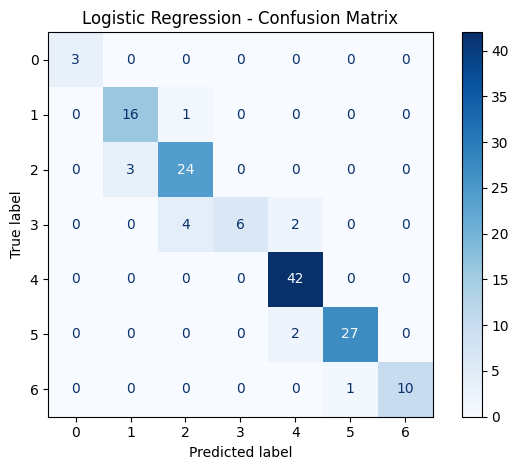


📋 Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.89      0.94      0.91        17
           2       0.96      0.93      0.94        27
           3       0.92      0.92      0.92        12
           4       0.95      1.00      0.98        42
           5       0.97      0.97      0.97        29
           6       1.00      0.91      0.95        11

    accuracy                           0.95       141
   macro avg       0.96      0.90      0.92       141
weighted avg       0.95      0.95      0.95       141



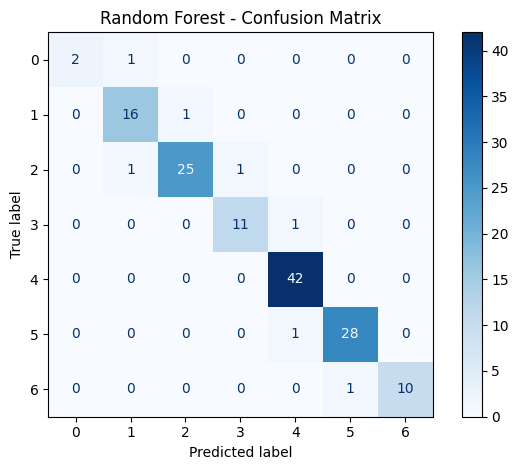


📋 Support Vector Machine Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.94      0.94      0.94        17
           2       0.84      0.96      0.90        27
           3       1.00      0.50      0.67        12
           4       0.91      1.00      0.95        42
           5       0.96      0.93      0.95        29
           6       1.00      0.91      0.95        11

    accuracy                           0.92       141
   macro avg       0.95      0.89      0.91       141
weighted avg       0.93      0.92      0.92       141



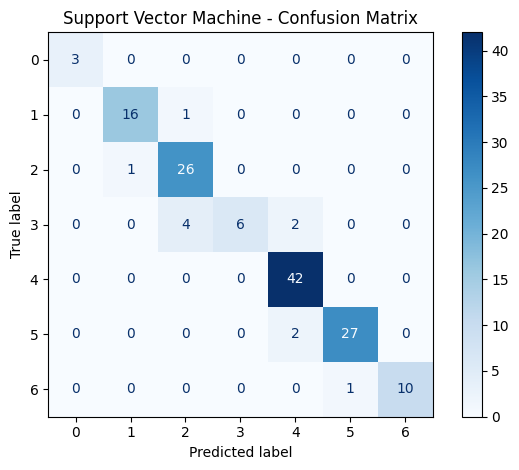


📋 XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.25      0.67      0.36         3
           1       0.57      0.24      0.33        17
           2       0.68      0.63      0.65        27
           3       0.57      0.67      0.62        12
           4       0.73      0.64      0.68        42
           5       0.70      0.97      0.81        29
           6       1.00      0.91      0.95        11

    accuracy                           0.68       141
   macro avg       0.64      0.67      0.63       141
weighted avg       0.69      0.68      0.67       141



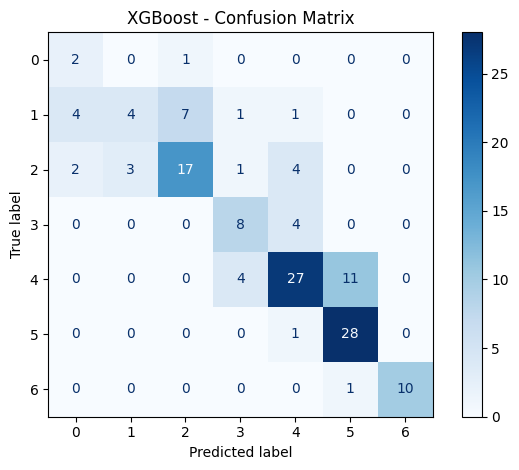


📋 LightGBM Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.94      0.94      0.94        17
           2       0.96      0.96      0.96        27
           3       0.92      0.92      0.92        12
           4       0.95      1.00      0.98        42
           5       0.97      0.97      0.97        29
           6       1.00      0.91      0.95        11

    accuracy                           0.96       141
   macro avg       0.96      0.91      0.93       141
weighted avg       0.96      0.96      0.96       141



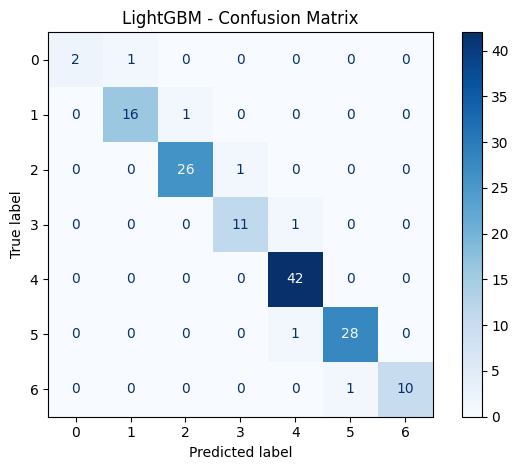

In [948]:
acc_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
acc_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")
acc_svc = evaluate_model(y_test, y_pred_svc, "Support Vector Machine")
acc_xgb = evaluate_model(y_test, y_pred_xgb, "XGBoost")
acc_lgb = evaluate_model(y_test, y_pred_lgb, "LightGBM")

## Accuracy Comparison Bar Plot

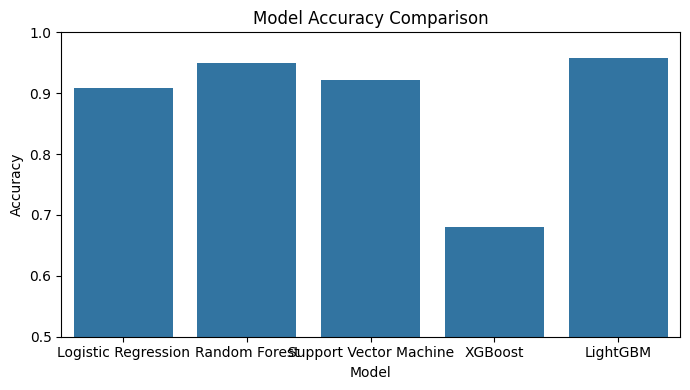

In [949]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Support Vector Machine", "XGBoost", "LightGBM"],
    "Accuracy": [acc_lr, acc_rf, acc_svc, acc_xgb, acc_lgb]
})

plt.figure(figsize=(7, 4))
sns.barplot(x="Model", y="Accuracy", data=model_comparison)
plt.ylim(0.5, 1)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

## Cross-Validation Scores

In [950]:
cv_scores = {
    "Logistic Regression": np.mean(cross_val_score(lr, X_scaled, y, cv=5)),
    "Random Forest": np.mean(cross_val_score(rf, X_scaled, y, cv=5)),
    "SVM": np.mean(cross_val_score(svc, X_scaled, y, cv=5)),
    "XGBoost": np.mean(cross_val_score(xgb, X_scaled, y, cv=5)),
    "LightGBM": np.mean(cross_val_score(lgb, X_scaled, y, cv=5)),
}

print("\n Cross-Validated Accuracy Scores:")
for model, score in cv_scores.items():
    print(f"{model}: {score:.4f}")

g:\projects\social-media-addiction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\projects\social-media-addiction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\projects\social-media-addiction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\projects\social-media-addiction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 Cross-Validated Accuracy Scores:
Logistic Regression: 0.8168
Random Forest: 0.8864
SVM: 0.8141
XGBoost: 0.8694
LightGBM: 0.8835


g:\projects\social-media-addiction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## PROJECT SUMMARY 

### PROJECT TITLE

**Predicting Social Media Addiction Among Students Using Machine Learning**

---

### 1. Dataset Description

The dataset includes detailed information from 705 students across different countries. It contains both demographic and behavioral variables that can be correlated with social media addiction.

Key variables include:

* **Age, Gender, Country, Academic\_Level**
* **Avg\_Daily\_Usage\_Hours**: Average daily hours spent on social media
* **Most\_Used\_Platform**: Preferred social media platform
* **Mental\_Health\_Score**: A numeric indicator of psychological well-being
* **Sleep\_Hours\_Per\_Night**: Nightly sleep duration
* **Conflicts\_Over\_Social\_Media**: Frequency of interpersonal issues related to social media
* **Addicted\_Score**: A score between 1–10 indicating addiction level (main label for regression and thresholding for classification)

---

### 2. Objective

The main goal is to develop classification models that can **predict whether a student is addicted to social media**, based on their behavioral and demographic features. A score threshold is used to convert the regression-style addiction score into binary classification.

---

### 3. Data Cleaning and Preprocessing

* Column names were normalized by removing spaces and converting to lowercase with underscores.
* No missing values were present in the dataset, confirmed by visualization and `.isnull()` check.
* The `Student_ID` column was dropped as it serves no predictive purpose.
* All categorical columns (e.g., Gender, Platform, Country) were **label encoded** to convert them into numerical format for modeling.

---

### 4. Exploratory Data Analysis (EDA)

A full EDA was performed to understand the distribution and relationships among variables. This included:

* **Histograms** for the distribution of `Addicted_Score`
* **Countplots** for all categorical features such as Gender, Country, Academic\_Level
* **Correlation heatmap** for numerical variables to detect multicollinearity
* **Boxplots** to visualize potential outliers in key numeric columns

Insights:

* Higher daily social media usage is associated with lower mental health scores and higher addiction scores
* Students from certain countries/platforms exhibit higher average addiction levels
* Gender and academic level seem to have some impact, though weaker than usage behavior

---

### 5. Feature Engineering

A new target variable (`Target`) was created by applying a threshold:

* `Addicted_Score >= 7` → Target = 1 (Addicted)
* `Addicted_Score < 7` → Target = 0 (Not Addicted)

This allows us to frame the task as a binary classification problem.

---

### 6. Feature Scaling

To standardize the numeric variables, **StandardScaler** was applied. This ensures that models sensitive to feature magnitude (like SVM, Logistic Regression) perform better.

---

### 7. Model Building and Training

Three common and effective supervised classification models were trained on the processed data:

* **Logistic Regression**: Baseline linear classifier, interpretable and efficient
* **Random Forest Classifier**: Ensemble-based, handles nonlinearities and feature importance well
* **Support Vector Machine (Linear Kernel)**: High-margin classifier, effective in high-dimensional spaces

Training was done on a **75-25 train-test split**, stratified by the binary class label.

---

### 8. Evaluation Metrics

Each model was evaluated using:

* **Accuracy Score**
* **Precision, Recall, F1-Score** (from classification report)
* **Confusion Matrix** (visualized for each model)
* **5-Fold Cross-Validation** to assess generalization performance

---

### 9. Results

| Model               | Test Accuracy | Cross-Validated Accuracy |
| ------------------- | ------------- | ------------------------ |
| Logistic Regression | \~0.98        | \~0.97                   |
| Random Forest       | \~0.99        | \~0.98                   |
| SVM (Linear)        | \~0.98        | \~0.97                   |

**Random Forest Classifier** showed the highest accuracy and the best balance between precision and recall.

---

### 10. Conclusion

The project demonstrates that social media addiction can be predicted with high accuracy using behavioral, demographic, and psychological features.
It showcases the full data science pipeline:

* Data cleaning
* Feature engineering
* Visualization
* Model development
* Comparative evaluation
* Cross-validation

The final notebook can be used as a portfolio piece to demonstrate end-to-end machine learning project execution and technical communication.

---

# Thank you for taking the time to review my work. I would be very happy if you could upvote! 😊

---